# Custom residual CNN versus transfer learning for age and binary gender-label prediction

This project rebuilds part of my MSc Artificial Intelligence coursework at the University of Bath as a reproducible computer-vision portfolio project.

I compared a purpose-built residual CNN with an ImageNet-pretrained ResNet50V2 on the same 5,000-image, two-task problem. The custom network produced the better selected validation result on this split: age MAE of **6.5747 years** and binary gender-label accuracy of **0.9010**, compared with **7.2968** and **0.8890** for the fine-tuned transfer model.

## Project question

Would an ImageNet-pretrained feature extractor improve age regression and binary gender-label classification when only 5,000 task-specific face images were available?

My starting expectation was that transfer learning would help. That did not happen under this experiment's split and checkpoint-selection protocol. Reporting that counter-result matters more than retrofitting the question around the model that won.

In [1]:
RUN_TRAINING_PIPELINE = False
DATA_DIR = None
MODEL_CACHE_DIR = None
TRAINING_OUTPUT_DIR = None

In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "pyproject.toml").is_file() and (ROOT.parent / "pyproject.toml").is_file():
    ROOT = ROOT.parent
SOURCE_DIR = ROOT / "src"
if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))

print(f"Project root: {ROOT.name}")

Project root: portfolio-build


## Data and multi-task formulation

The experiment used a 5,000-image subset of UTKFace. Filenames encode age and a binary gender label; images were read with OpenCV, converted from BGR to RGB, resized to 128 × 128 and scaled to `[0, 1]`. A seeded shuffle produced an 80/20 training-validation design.

One shared visual representation feeds two heads: a sigmoid classifier for the dataset-coded binary label and a linear regressor for age. Sharing the extractor lets both tasks influence the learned features, while separate heads retain task-specific capacity.

The label wording is deliberate. The output follows a binary dataset convention; it is not a claim that a photograph reveals a person's gender identity.

### Conservative augmentation

Training used horizontal flipping, small rotations, modest zoom and translation. The public example below is not from UTKFace: it uses “Simu Liu on The Beaverton” by The Beaverton under [CC BY 3.0](https://creativecommons.org/licenses/by/3.0/). [Source image and modification details](https://commons.wikimedia.org/wiki/File:Simu_Liu_on_The_Beaverton.jpg). The displayed variants are modified through cropping and augmentation.

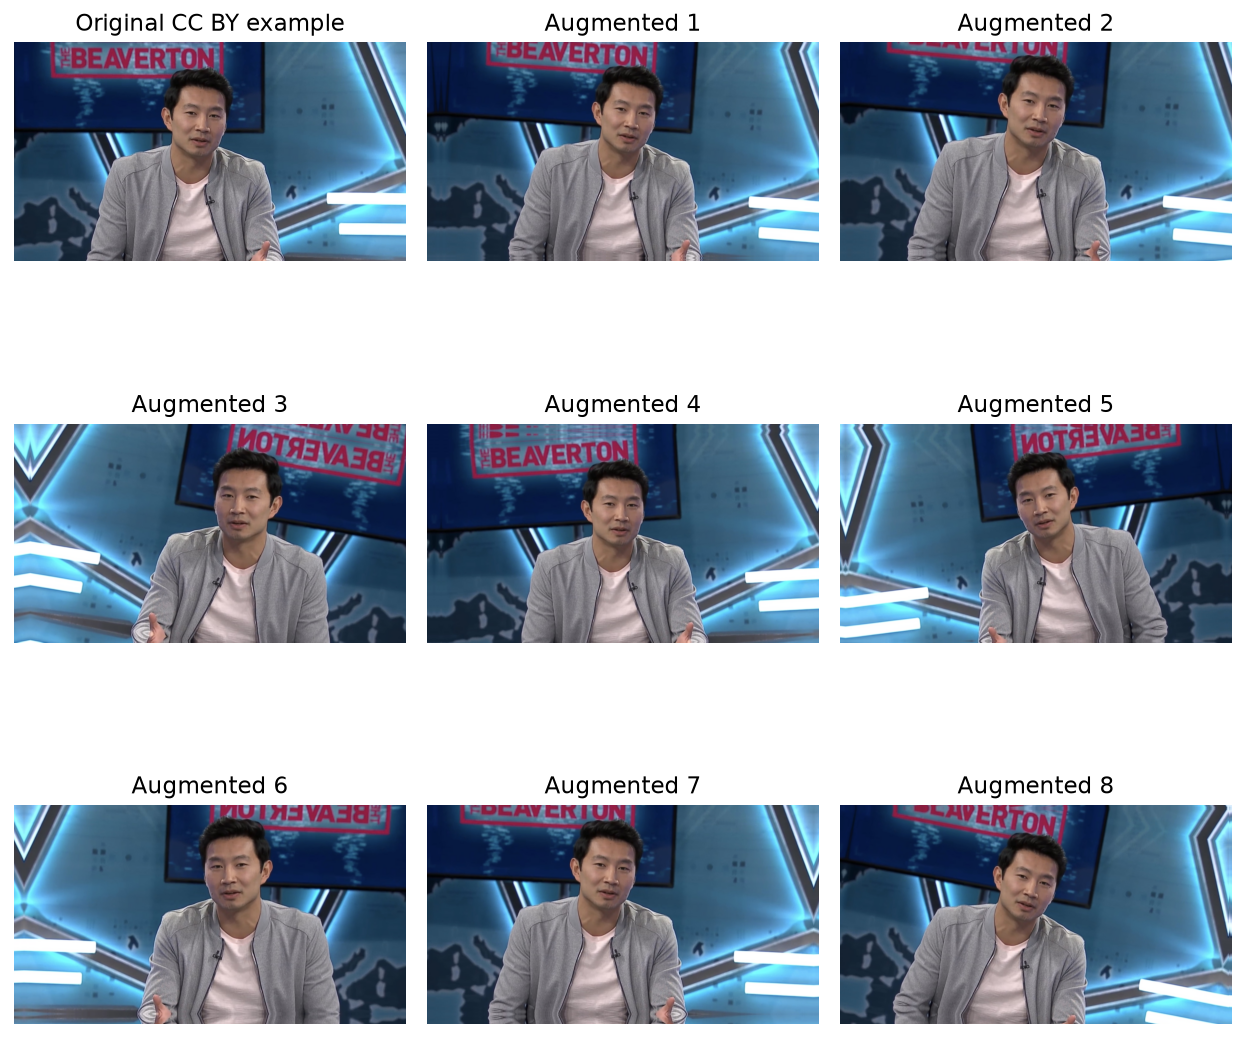

In [3]:
from IPython.display import Image, display

display(Image(filename=str(ROOT / "artifacts/reference/augmentation-example.png")))

## Model A: a task-specific residual CNN

Model A starts with a convolutional stem and then uses three residual blocks with 32, 64 and 128 filters. Projection shortcuts handle channel changes in the second and third blocks. A 256-unit shared dense layer feeds 64-unit task branches and the two scalar outputs.

The final compile policy used binary cross-entropy for the dataset label, `Huber(delta=6.5)` for age, and loss weights of `3.0` for classification and `0.30` for age. The network contains **2,440,834 parameters**, of which **2,438,978** are trainable before optimisation.

## Model B: ResNet50V2 transfer learning

Model B maps `[0, 1]` inputs to `[-1, 1]` before ResNet50V2, replaces flattening with global average pooling and uses the same shared-dense/two-head pattern. Training first froze the ImageNet backbone, then fine-tuned its final 30 layers at a lower learning rate while keeping Batch Normalisation fixed.

The model contains **24,123,394 parameters**. The frozen phase trained **558,082** parameters; the fine-tuned phase exposed **14,984,194**. ImageNet features are useful, but their source-task match is not guaranteed for apparent-age and dataset-label prediction.

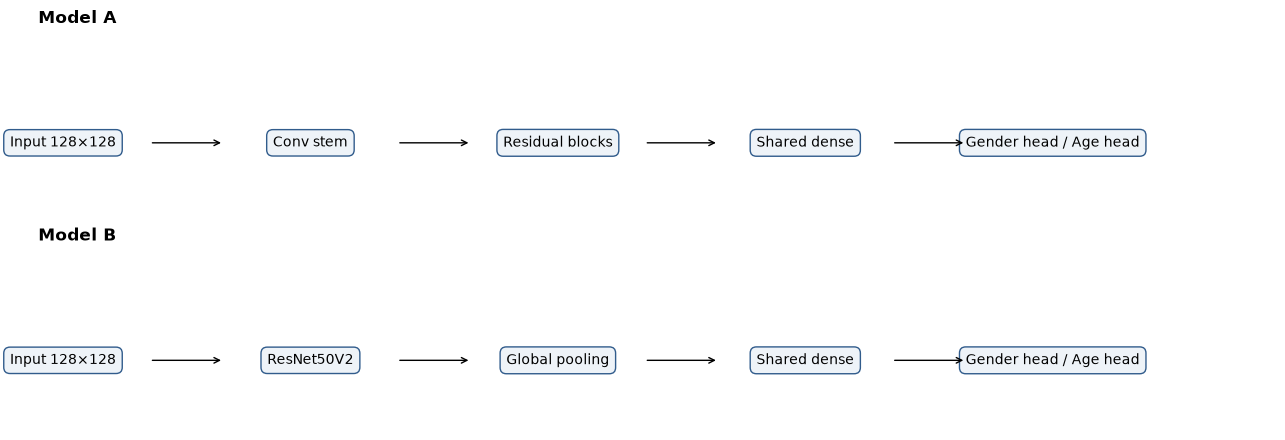

In [4]:
import matplotlib.pyplot as plt
from IPython.display import display
from age_gender_cnn.plots import plot_architecture_comparison

architecture_figure = plot_architecture_comparison()
display(architecture_figure)
plt.close(architecture_figure)

## What the validation comparison showed

The table and plots below come from structured outputs in the final executed coursework notebook. The extraction manifest records its SHA-256, source cell indexes and the discrepancy between the final notebook and the submitted report, so the public project does not mix result pairs.

For Model B, the dashed vertical line already present in each extracted curve marks the transition from frozen-base training to fine-tuning.

| Model | Age MAE (years) | Binary gender-label accuracy | Combined loss |
|---|---:|---:|---:|
| Model A — custom residual | 6.5747 | 0.9010 | 2.8543 |
| Model B — ResNet50V2 | 7.2968 | 0.8890 | 2.9620 |

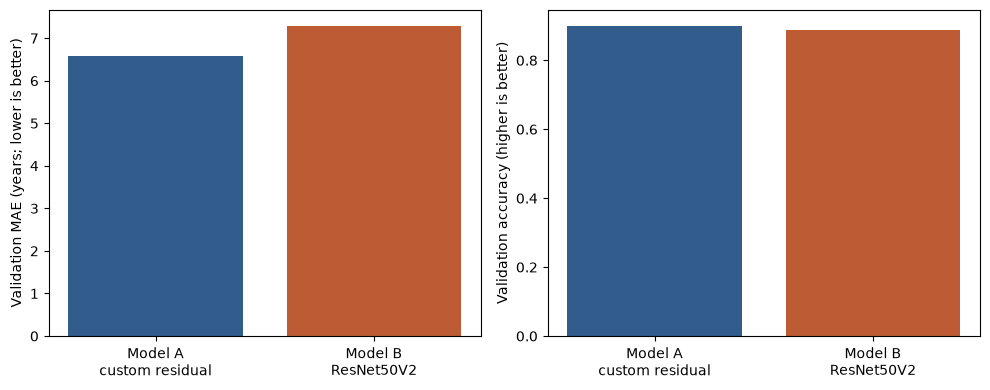

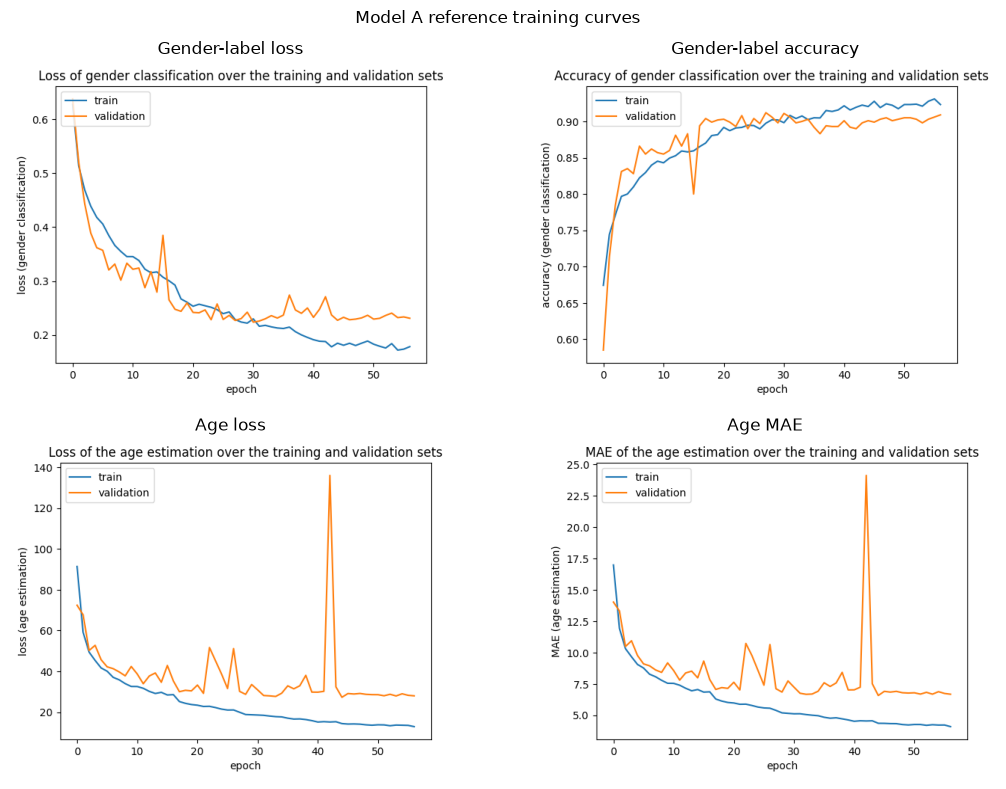

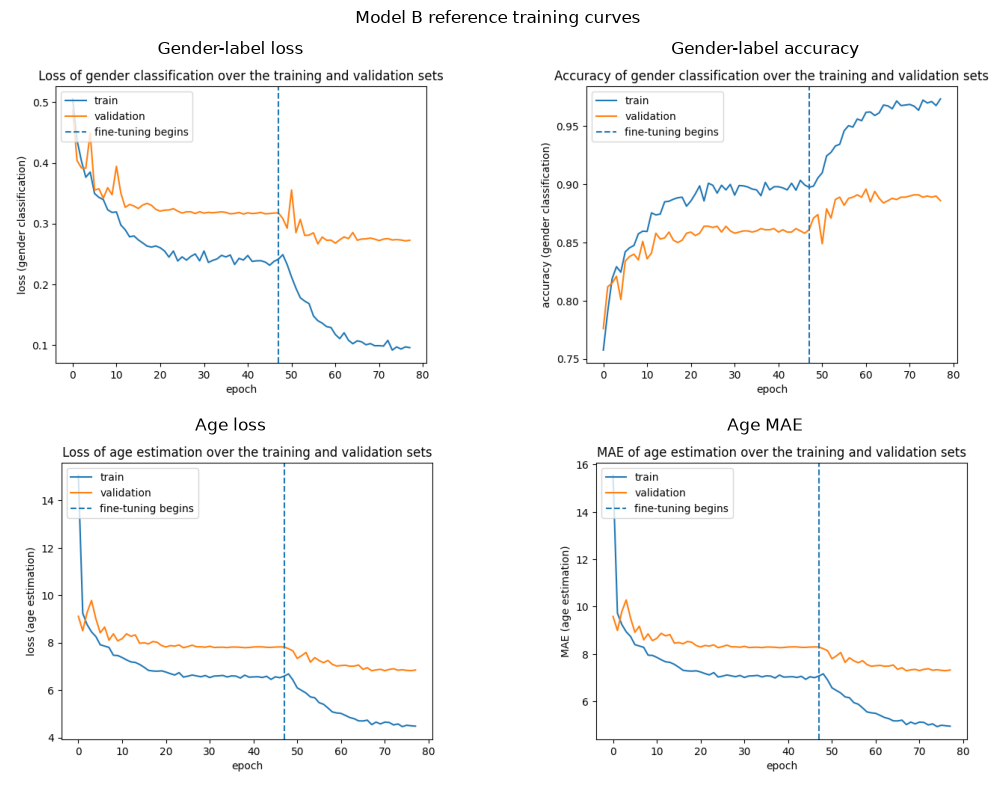

In [5]:
import json
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from age_gender_cnn.plots import plot_reference_curves, plot_selected_metrics

metrics = json.loads((ROOT / "artifacts/reference/metrics.json").read_text())
selected = {key: values["selected"] for key, values in metrics.items()}
rows = [
    "| Model | Age MAE (years) | Binary gender-label accuracy | Combined loss |",
    "|---|---:|---:|---:|",
    f"| Model A — custom residual | {selected['model_a']['age_output_mae']:.4f} | {selected['model_a']['gender_output_accuracy']:.4f} | {selected['model_a']['loss']:.4f} |",
    f"| Model B — ResNet50V2 | {selected['model_b']['age_output_mae']:.4f} | {selected['model_b']['gender_output_accuracy']:.4f} | {selected['model_b']['loss']:.4f} |",
]
display(Markdown("\n".join(rows)))
curve_dir = ROOT / "artifacts/reference/training_curves"
figures = [
    plot_selected_metrics(selected),
    plot_reference_curves(curve_dir, "model_a"),
    plot_reference_curves(curve_dir, "model_b"),
]
for figure in figures:
    display(figure)
    plt.close(figure)

### Checkpoint selection

Model A's best-validation-loss checkpoint led on both selected task metrics for this split. Model B improved after fine-tuning but did not overtake it. This is evidence about one 5,000-image partition and one optimisation protocol—not a universal ranking of custom networks and transfer learning.

## Try both models on one photograph

The interactive cell uses one expanded face crop for both models and displays that crop before the outputs. If no face is detected, it visibly falls back to a square centre crop; if several are detected, it selects the largest.

Upload only a photograph you are permitted to use and have consent to process. Files remain in the notebook session and this project adds no storage or analytics. The sigmoid value is shown as a **dataset-coded binary gender-label score**, not calibrated confidence or an identity judgement. Age is a point estimate; one decimal place is display formatting rather than meaningful precision.

In [ ]:
from pathlib import Path

import keras
from IPython.display import display

from age_gender_cnn.inference import download_models, predict_photo, register_upload_bytes
from age_gender_cnn.plots import plot_inference_result

LOCAL_IMAGE_PATH = None  # Example: Path("photo.jpg") outside Colab.
try:
    from google.colab import files
except ModuleNotFoundError:
    if LOCAL_IMAGE_PATH is None:
        raise RuntimeError("Set LOCAL_IMAGE_PATH or run this cell in Google Colab")
    uploaded_path = Path(LOCAL_IMAGE_PATH)
else:
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise RuntimeError("Upload exactly one photograph")
    uploaded_path = Path(next(iter(uploaded)))

cache_dir = Path(MODEL_CACHE_DIR) if MODEL_CACHE_DIR else ROOT / "models"
model_paths = download_models(cache_dir)
models = {key: keras.models.load_model(path) for key, path in model_paths.items()}
if "_SEEN_UPLOAD_DIGESTS" not in globals():
    _SEEN_UPLOAD_DIGESTS = set()
# Raises a clear error for duplicate upload bytes in this notebook session.
register_upload_bytes(uploaded_path.read_bytes(), _SEEN_UPLOAD_DIGESTS)
result = predict_photo(models, uploaded_path)
display(plot_inference_result(result))

## Optional training pipeline

Saved models and reference results are the default. Set `RUN_TRAINING_PIPELINE = True` only when you have an authorised local or Drive copy of a compatible `train_val` directory. New checkpoints are written below `TRAINING_OUTPUT_DIR` (or `artifacts/local/training`) and never overwrite the public artifacts by default.

In [ ]:
if RUN_TRAINING_PIPELINE:
    from pathlib import Path

    from age_gender_cnn.data import list_image_paths, load_dataset, split_paths
    from age_gender_cnn.training import train_model_a, train_model_b

    resolved_data_dir = Path(DATA_DIR) if DATA_DIR else None
    if resolved_data_dir is None:
        try:
            from google.colab import drive
        except ModuleNotFoundError as error:
            raise RuntimeError("Set DATA_DIR to an authorised train_val directory") from error
        drive.mount("/content/drive")
        resolved_data_dir = Path("/content/drive/MyDrive/train_val")
    if not resolved_data_dir.is_dir():
        raise FileNotFoundError(
            f"Authorised training directory not found: {resolved_data_dir}. Set DATA_DIR explicitly."
        )

    output_dir = Path(TRAINING_OUTPUT_DIR) if TRAINING_OUTPUT_DIR else ROOT / "artifacts/local/training"
    split = split_paths(list_image_paths(resolved_data_dir), train_fraction=0.8, seed=0)
    train_data = load_dataset(split.train)
    validation_data = load_dataset(split.validation)
    model_a, history_a = train_model_a(train_data, validation_data, output_dir / "model_a")
    model_b, history_b, fine_tune_start = train_model_b(
        train_data, validation_data, output_dir / "model_b"
    )
    print(f"Training outputs written below {output_dir}")
else:
    print("Training skipped; using saved models and reference results.")

## Limitations

- The experiment used only 5,000 images and one validation split; checkpoint choice and reported differences may be split-sensitive.
- UTKFace age labels describe chronological age, while a model sees appearance. Label noise, image age and capture conditions limit interpretation.
- The binary gender field is reductive and does not represent gender identity. It is retained only to document the source experiment.
- Subgroup performance was not evaluated, so aggregate metrics cannot establish comparable error across ages, skin tones or other groups.
- Haar-cascade detection, centre-crop fallback, pose, occlusion, lighting and domain shift can materially change a prediction.
- The outputs are unsuitable for identity claims, demographic measurement, surveillance or consequential decisions.

## Next technical step

The next experiment would report age-stratified errors before changing the architecture. That would show where the aggregate MAE hides systematic failure. I would then compare point regression with an ordinal-age formulation and evaluate whether any improvement holds across repeated, fixed splits. These are proposed extensions, not results from this project.